**Panda MNIST**

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import zipfile
import matplotlib.pyplot as plt
import cv2

nahraj pre_judging_script.py, test_data.npz, train_data.zip

In [2]:
torch.manual_seed(42)
np.random.seed(42)

In [3]:
torch.cuda.is_available()

True

Subtask 1

In [4]:
# Load training data from subtask1/
def load_subtask1_data():
    with zipfile.ZipFile("train_data.zip", "r") as zf:
        train_data = {}
        for name in zf.namelist():
            if name.startswith("subtask1/") and name.endswith(".npy"):
                with zf.open(name) as f:
                    train_data[name] = np.load(f)

    # Concatenate all three scanners
    sub1_X = []
    sub1_y = []
    for s in [1, 2, 3]:
        x = train_data[f"subtask1/scanner{s}_X.npy"].astype(np.float32) / 255.0
        y = train_data[f"subtask1/scanner{s}_y.npy"].astype(np.int64)
        sub1_X.append(x)
        sub1_y.append(y)
    X1 = np.concatenate(sub1_X, axis=0)
    y1 = np.concatenate(sub1_y, axis=0)
    print(X1.shape, y1.shape)
    return X1, y1

In [5]:
X1, y1 = load_subtask1_data()

(1500, 1, 28, 28) (1500,)


In [6]:
X1[0,0].min(), X1[0,0].max()

(np.float32(0.0), np.float32(1.0))

In [7]:
y1[0]

np.int64(2)

In [8]:
def identity(x):
    return x
def view_samples(ofs=1090, modifier=identity):
    for i in range(10):
        input_img = (modifier(X1[i+ofs])[0]*255).astype(np.uint8)
        plt.subplot(2, 10, i+1)
        plt.title(f"{y1[i+ofs]}")
        plt.imshow(input_img, cmap='gray')
        plt.axis('off')
    plt.show()

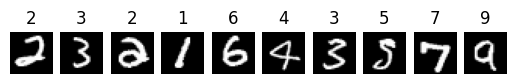

In [9]:
view_samples(0)

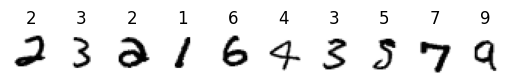

In [10]:
view_samples(500)

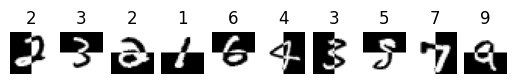

In [11]:
view_samples(1000)

In [12]:
test_data = np.load("test_data.npz")

In [13]:
test_data['scanner1'].shape

(2000, 1, 28, 28)

In [14]:
test_data['scanner1_labels']

array([0, 9, 1, ..., 6, 4, 3])

In [15]:
XX1 = np.concatenate([test_data[f'scanner{i}'] for i in [1,2,3]]).astype(np.float32)/255
yy1 = np.concatenate([test_data[f'scanner{i}_labels'] for i in [1,2,3]])

In [16]:
XX1.shape, yy1.shape, XX1.max(), XX1.min()

((6000, 1, 28, 28), (6000,), np.float32(1.0), np.float32(0.0))

In [17]:
def view_test_samples(ofs=1090, modifier=identity):
    for i in range(10):
        input_img = (modifier(XX1[i+ofs])[0]*255).astype(np.uint8)
        plt.subplot(2, 10, i+1)
        plt.title(f"{yy1[i+ofs]}")
        plt.imshow(input_img, cmap='gray')
        plt.axis('off')
    plt.show()

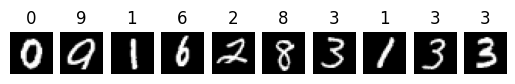

In [18]:
view_test_samples(0)

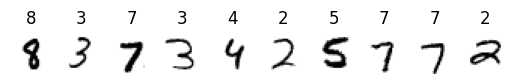

In [19]:
view_test_samples(2000)

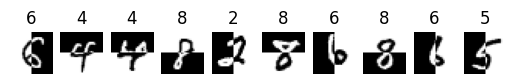

In [20]:
view_test_samples(4000)

In [21]:
def fix(x):
    nobatch = (len(x.shape) == 3)
    if nobatch:
        x = x[None]
    B, C, H, W = x.shape
    for b in range(B):
        xb = x[b]
        candidates = np.stack([
            xb,
            1 - xb,
            np.concatenate([1 - xb[:, :H//2, :], xb[:, H//2:, :]], axis=1),
            np.concatenate([xb[:, :H//2, :], 1 - xb[:, H//2:, :]], axis=1),
            np.concatenate([1 - xb[:, :, :W//2], xb[:, :, W//2:]], axis=2),
            np.concatenate([xb[:, :, :W//2], 1 - xb[:, :, W//2:]], axis=2),
        ], axis=0)
        qualities = candidates.sum(axis=(1, 2, 3))
        best = qualities.argmin()
        x[b] = candidates[best]
    if nobatch:
        x = x[0]
    return x

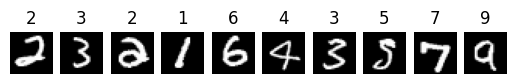

In [22]:
view_samples(0,fix)

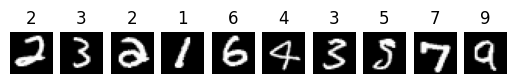

In [23]:
view_samples(500,fix)

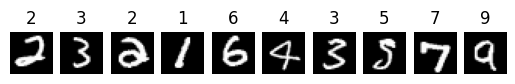

In [24]:
view_samples(1000,fix)

In [25]:
def augmentation(x):
    x = np.copy(x)
    prob = np.random.rand(len(x))
    for i, x_i in enumerate(x):
        if prob[i] < 0.5:
            angle = float(np.random.rand(1)[0]*30-15) #dg
            center = (x_i.shape[1]/2, x_i.shape[0]/2)
            rot = cv2.getRotationMatrix2D(center, angle, 1.0)
            x_i = cv2.warpAffine(x_i, rot, (x_i.shape[1], x_i.shape[0]))
            tr = (np.random.rand(2)-0.5)*4
            M = np.float32([[1, 0, tr[0]], [0, 1, tr[1]]])
            x[i] = cv2.warpAffine(x_i, M, (x_i.shape[1], x_i.shape[0]))
    return x

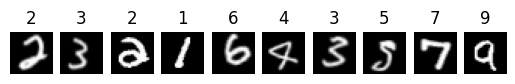

In [26]:
view_samples(0,augmentation)

In [27]:
# add test data
X1 = np.concatenate([X1,XX1],axis=0)
y1 = np.concatenate([y1,yy1],axis=0)

In [28]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(16 * 7 * 7, num_classes),
        )

    def forward(self, x):
        # Handles both 1-ch (subtask1) and 3-ch (subtask2) input.
        # For subtask2, converts RGB to grayscale!
        if x.shape[1] == 3:
            x = 0.299 * x[:, 0:1] + 0.587 * x[:, 1:2] + 0.114 * x[:, 2:3]
        return self.net(x)

In [29]:
def penalty(model):
    return sum(p.numel() for p in model.parameters()) / 7500

In [30]:
def train_model(model, X, y, XX=None, yy=None, epochs=10, augmentation=identity, lr=0.001, batch_size=50):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    print(f'penalty: {penalty(model):.2f}')
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    X_a = augmentation(X)
    X_t = torch.from_numpy(X_a).to(device)
    y_t = torch.from_numpy(y).long().to(device)
    XX_t = torch.from_numpy(X if XX is None else XX).to(device)
    yy_t = torch.from_numpy(y if yy is None else yy).long().to(device)

    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(len(y))
        total_loss = 0.0
        for start in range(0, len(y), batch_size):
            idx = perm[start:start + batch_size]
            opt.zero_grad()
            loss = loss_fn(model(X_t[idx]), y_t[idx])
            loss.backward()
            opt.step()
            total_loss += loss.item()

        model.eval()
        with torch.no_grad():
            acc = (model(X_t).argmax(1) == y_t).float().mean().item()
        with torch.no_grad():
            testacc = (model(XX_t).argmax(1) == yy_t).float().mean().item()
        print(f"  epoch {epoch:2d}: loss={total_loss:.4f}  acc={acc:.4f} testacc={testacc:.4f}")
        if testacc == 1.0:
            break

    model.eval()
    return model.cpu()

In [31]:
# Train Subtask 1 starter model
model1 = SimpleCNN()
params1 = sum(p.numel() for p in model1.parameters())
print(f"  params: {params1:,}")
model1 = train_model(model1, X1, y1, XX1, yy1, epochs=40) #, augmentation=augmentation

  params: 9,098
penalty: 1.21
  epoch  0: loss=252.2212  acc=0.8319 testacc=0.8313
  epoch  1: loss=65.7894  acc=0.9203 testacc=0.9208
  epoch  2: loss=39.4548  acc=0.9396 testacc=0.9383
  epoch  3: loss=30.2937  acc=0.9532 testacc=0.9522
  epoch  4: loss=24.5460  acc=0.9640 testacc=0.9637
  epoch  5: loss=19.9828  acc=0.9679 testacc=0.9677
  epoch  6: loss=18.2945  acc=0.9649 testacc=0.9657
  epoch  7: loss=16.2002  acc=0.9705 testacc=0.9707
  epoch  8: loss=14.2976  acc=0.9703 testacc=0.9708
  epoch  9: loss=12.8035  acc=0.9797 testacc=0.9787
  epoch 10: loss=11.3345  acc=0.9841 testacc=0.9840
  epoch 11: loss=10.2629  acc=0.9784 testacc=0.9778
  epoch 12: loss=9.2572  acc=0.9840 testacc=0.9840
  epoch 13: loss=8.5155  acc=0.9855 testacc=0.9848
  epoch 14: loss=7.2017  acc=0.9875 testacc=0.9875
  epoch 15: loss=7.2421  acc=0.9889 testacc=0.9882
  epoch 16: loss=6.5325  acc=0.9904 testacc=0.9908
  epoch 17: loss=5.6250  acc=0.9944 testacc=0.9947
  epoch 18: loss=5.5585  acc=0.9949 tes

In [32]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), # 16 x 28 x 28
            nn.SiLU(),
            nn.MaxPool2d(2), # 16 x 14 x 14
            nn.Conv2d(16, 8, 3, padding=0), # 8 x 12 x 12
            nn.SiLU(),
            nn.MaxPool2d(2), # 8 x 6 x 6
            nn.Flatten(),
            nn.LayerNorm(8 * 6 * 6),
            nn.Linear(8 * 6 * 6, num_classes, bias=False),
        )

    @staticmethod
    def fix(x):
        B,C,H,W = x.shape
        for b in range(B):
            xb = x[b]
            candidates = torch.stack([
                xb,
                1-xb,
                torch.cat([1-xb[:,:H//2,:],xb[:,H//2:,:]],dim=1),
                torch.cat([xb[:,:H//2,:],1-xb[:,H//2:,:]],dim=1),
                torch.cat([1-xb[:,:,:W//2],xb[:,:,W//2:]],dim=2),
                torch.cat([xb[:,:,:W//2],1-xb[:,:,W//2:]],dim=2),
            ], dim=0)
            qualities = candidates.sum(dim=[1,2,3])
            best = qualities.argmin()
            x[b] = candidates[best]
        return x

    def forward(self, x):
        # Handles both 1-ch (subtask1) and 3-ch (subtask2) input.
        # For subtask2, converts RGB to grayscale!
        if x.shape[1] == 3:
            x = 0.299 * x[:, 0:1] + 0.587 * x[:, 1:2] + 0.114 * x[:, 2:3]
        if not self.training:
            x = SimpleCNN.fix(x)
        return self.net(x)

In [33]:
# Train Subtask 1 model
model1 = SimpleCNN()
params1 = sum(p.numel() for p in model1.parameters())
print(f"  params: {params1:,} penalty: {params1/7500:.1f}")
model1 = train_model(model1, fix(X1), y1, XX1, yy1, epochs=20) #, augmentation=augmentation

  params: 4,776 penalty: 0.6
penalty: 0.64
  epoch  0: loss=140.0732  acc=0.9089 testacc=0.9137
  epoch  1: loss=40.2823  acc=0.9548 testacc=0.9545
  epoch  2: loss=24.4690  acc=0.9672 testacc=0.9670
  epoch  3: loss=18.0877  acc=0.9761 testacc=0.9757
  epoch  4: loss=14.5499  acc=0.9819 testacc=0.9813
  epoch  5: loss=11.8579  acc=0.9859 testacc=0.9848
  epoch  6: loss=9.6927  acc=0.9868 testacc=0.9865
  epoch  7: loss=8.5014  acc=0.9915 testacc=0.9913
  epoch  8: loss=6.7886  acc=0.9953 testacc=0.9947
  epoch  9: loss=6.0614  acc=0.9937 testacc=0.9932
  epoch 10: loss=5.1199  acc=0.9963 testacc=0.9958
  epoch 11: loss=4.4129  acc=0.9972 testacc=0.9965
  epoch 12: loss=3.8425  acc=0.9976 testacc=0.9975
  epoch 13: loss=3.2106  acc=0.9987 testacc=0.9983
  epoch 14: loss=2.8261  acc=0.9991 testacc=0.9988
  epoch 15: loss=2.4334  acc=0.9989 testacc=0.9987
  epoch 16: loss=2.1974  acc=0.9995 testacc=0.9993
  epoch 17: loss=1.8421  acc=0.9999 testacc=0.9998
  epoch 18: loss=1.6136  acc=1.0

In [34]:
# Export Subtask 1 model with jit.script
model1.eval();
script1 = torch.jit.script(model1)
torch.jit.save(script1, "model_sub1.pt")
print(f"Exported model_sub1.pt")

Exported model_sub1.pt


Subtask 2

In [35]:
# Load training data from subtask2/
def load_subtask2_data():
    with zipfile.ZipFile("train_data.zip", "r") as zf:
        train_data = {}
        for name in zf.namelist():
            if name.startswith("subtask2/") and name.endswith(".npy"):
                with zf.open(name) as f:
                    train_data[name] = np.load(f)

    # Concatenate all eight scanners
    sub2_X = []
    sub2_y = []
    for s in range(1, 9):
        x = train_data[f"subtask2/scanner{s}_X.npy"].astype(np.float32) / 255.0
        y = train_data[f"subtask2/scanner{s}_y.npy"].astype(np.int64)
        sub2_X.append(x)
        sub2_y.append(y)
    X2 = np.concatenate(sub2_X, axis=0)
    y2 = np.concatenate(sub2_y, axis=0)
    print(X2.shape, y2.shape)
    return X2, y2

In [36]:
X2, y2 = load_subtask2_data()

(4000, 3, 28, 28) (4000,)


In [37]:
[test_data[f'scanner{i}'].shape for i in [1,2,3,4,5,6,7,8]]

[(2000, 1, 28, 28),
 (2000, 1, 28, 28),
 (2000, 1, 28, 28),
 (2000, 3, 28, 28),
 (2000, 1, 28, 28),
 (2000, 1, 28, 28),
 (2000, 1, 28, 28),
 (2000, 1, 28, 28)]

In [38]:
def rgb(x):
    if x.shape[1] == 1:
        return np.concatenate([x,x,x],axis=1)
    return x

In [39]:
XX2 = np.concatenate([rgb(test_data[f'scanner{i}']) for i in [1,2,3,4,5,6,7,8]]).astype(np.float32)/255
yy2 = np.concatenate([test_data[f'scanner{i}_labels'] for i in [1,2,3,4,5,6,7,8]])

In [40]:
XX2.shape, yy2.shape, XX2.max(), XX2.min()

((16000, 3, 28, 28), (16000,), np.float32(1.0), np.float32(0.0))

In [41]:
def identity(x):
    return x
def view_samples2(ofs=1090, modifier=identity):
    for i in range(10):
        input_img = cv2.merge((modifier(X2[i+ofs])*255).astype(np.uint8))
        plt.subplot(2, 10, i+1)
        plt.title(f"{y2[i+ofs]}")
        plt.imshow(input_img, cmap='gray')
        plt.axis('off')
    plt.show()

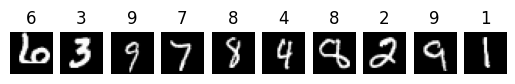

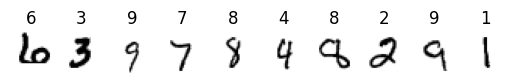

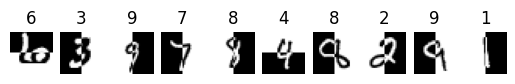

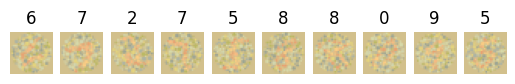

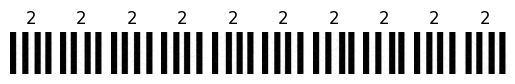

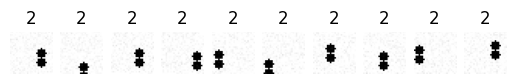

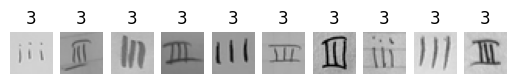

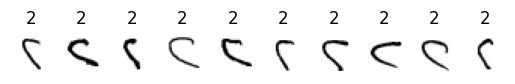

In [42]:
for ofs in range(0,4000,500):
    view_samples2(ofs+100)

In [43]:
# kinds
k2 = np.repeat(np.arange(8), len(X2) // 8)
kk2 = np.repeat(np.arange(8), len(XX2) // 8)

In [44]:
# add test data
X2 = np.concatenate([X2,XX2],axis=0)
y2 = np.concatenate([y2,yy2],axis=0)
k2 = np.concatenate([k2,kk2],axis=0)

In [45]:
len(X2), len(y2), len(k2)

(20000, 20000, 20000)

In [46]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 8, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(16 * 7 * 7, num_classes),
        )

    def forward(self, x):
        return self.net(x)

In [47]:
# Train Subtask 2 starter model
model2 = SimpleCNN()
params2 = sum(p.numel() for p in model2.parameters())
print(f"  params: {params2:,}")
model2 = train_model(model2, X2, y2, XX2, yy2, epochs=100)

  params: 9,242
penalty: 1.23
  epoch  0: loss=637.2483  acc=0.6004 testacc=0.6003
  epoch  1: loss=444.2816  acc=0.6660 testacc=0.6663
  epoch  2: loss=395.8081  acc=0.7147 testacc=0.7139
  epoch  3: loss=361.8170  acc=0.7110 testacc=0.7100
  epoch  4: loss=331.8951  acc=0.7420 testacc=0.7401
  epoch  5: loss=300.2858  acc=0.7834 testacc=0.7831
  epoch  6: loss=271.6979  acc=0.8004 testacc=0.8013
  epoch  7: loss=247.8167  acc=0.8014 testacc=0.8016
  epoch  8: loss=231.3234  acc=0.8117 testacc=0.8124
  epoch  9: loss=217.0515  acc=0.8335 testacc=0.8344
  epoch 10: loss=206.6728  acc=0.8445 testacc=0.8451
  epoch 11: loss=197.5702  acc=0.8439 testacc=0.8451
  epoch 12: loss=189.9940  acc=0.8584 testacc=0.8604
  epoch 13: loss=181.7341  acc=0.8679 testacc=0.8691
  epoch 14: loss=176.8752  acc=0.8634 testacc=0.8641
  epoch 15: loss=170.0937  acc=0.8778 testacc=0.8793
  epoch 16: loss=165.6711  acc=0.8674 testacc=0.8678
  epoch 17: loss=159.6038  acc=0.8741 testacc=0.8749
  epoch 18: loss

In [48]:
model2 = train_model(model2, X2, y2, XX2, yy2, epochs=1)

penalty: 1.23
  epoch  0: loss=46.3092  acc=0.9652 testacc=0.9673


In [49]:
# Export Subtask 2 model with jit.script
model2.eval();
script2 = torch.jit.script(model2)
torch.jit.save(script2, "model_sub2.pt")
print(f"Exported model_sub2.pt")

Exported model_sub2.pt


tento model boduje 70 zo 70, takze staci. Ale taketo ulohy sa riesia cez Mixture of Experts

In [50]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10, num_kinds=8):
        super().__init__()

        self.num_kinds = num_kinds
        self.num_classes = num_classes

        self.backbone = nn.Sequential(
            nn.Conv2d(3, 8, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
        )
        # router
        self.router = nn.Sequential(
            nn.Linear(16 * 7 * 7, num_kinds),
        )

        # experts
        self.experts = nn.ModuleList([
            nn.Linear(16 * 7 * 7, num_classes)
            for _ in range(num_kinds)
        ])

    def forward(self, x):
        # run backbone
        feats =self.backbone(x)

        # run router
        gate_logits = self.router(feats)

        # calculate relevance of experts
        gate_probs = F.softmax(gate_logits, dim=1)

        # run all experts in parallel (script-safe!)
        expert_outs = []
        for expert in self.experts:
            expert_outs.append(expert(feats).unsqueeze(1))

        expert_outs = torch.cat(expert_outs, dim=1)

        # weighted sum over experts
        logits = torch.sum(expert_outs * gate_probs.unsqueeze(-1), dim=1)

        if not torch.jit.is_scripting():
            if self.training:
                return logits, gate_logits # here we can include that we know the id of the expert during the training

        return logits

In [51]:
def train_model2(model, X, y, k, XX=None, yy=None, epochs=10, lr=0.001, batch_size=50):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    print(f'penalty: {penalty(model):.2f}')
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    X_t = torch.from_numpy(X).to(device)
    y_t = torch.from_numpy(y).long().to(device)
    k_t = torch.from_numpy(k).long().to(device)

    XX_t = torch.from_numpy(X if XX is None else XX).to(device)
    yy_t = torch.from_numpy(y if yy is None else yy).long().to(device)

    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(len(y))
        total_loss = 0.0
        for start in range(0, len(y), batch_size):
            idx = perm[start:start + batch_size]
            opt.zero_grad()
            y_l, k_l = model(X_t[idx])
            loss = 0.7*loss_fn(k_l, k_t[idx]) + 0.3*loss_fn(y_l, y_t[idx])
            loss.backward()
            opt.step()
            total_loss += loss.item()

        model.eval()
        with torch.no_grad():
            acc = (model(X_t).argmax(1) == y_t).float().mean().item()
        with torch.no_grad():
            testacc = (model(XX_t).argmax(1) == yy_t).float().mean().item()
        print(f"  epoch {epoch:2d}: loss={total_loss:.4f}  acc={acc:.4f} testacc={testacc:.4f}")

        if testacc > 0.99:
            break

    model.eval()
    return model.cpu()

In [52]:
# Train Subtask 2 model
model2 = SimpleCNN()
params2 = sum(p.numel() for p in model2.parameters())
print(f"  params: {params2:,}")
model2 = train_model2(model2, X2, y2, k2, XX2, yy2, epochs=60)

  params: 70,472
penalty: 9.40
  epoch  0: loss=304.3477  acc=0.6474 testacc=0.6476
  epoch  1: loss=146.1278  acc=0.7127 testacc=0.7119
  epoch  2: loss=115.2290  acc=0.7447 testacc=0.7448
  epoch  3: loss=98.7373  acc=0.7782 testacc=0.7796
  epoch  4: loss=86.0803  acc=0.7947 testacc=0.7951
  epoch  5: loss=79.1316  acc=0.8388 testacc=0.8401
  epoch  6: loss=71.3937  acc=0.8580 testacc=0.8604
  epoch  7: loss=65.2743  acc=0.8655 testacc=0.8675
  epoch  8: loss=58.5095  acc=0.8755 testacc=0.8779
  epoch  9: loss=52.2117  acc=0.8895 testacc=0.8925
  epoch 10: loss=52.9240  acc=0.8913 testacc=0.8920
  epoch 11: loss=44.8431  acc=0.8823 testacc=0.8854
  epoch 12: loss=41.7096  acc=0.9114 testacc=0.9135
  epoch 13: loss=40.5228  acc=0.8988 testacc=0.9004
  epoch 14: loss=35.8116  acc=0.9187 testacc=0.9221
  epoch 15: loss=39.5518  acc=0.8946 testacc=0.8963
  epoch 16: loss=33.6133  acc=0.9366 testacc=0.9397
  epoch 17: loss=29.0191  acc=0.9171 testacc=0.9190
  epoch 18: loss=27.7236  acc=

Submission

In [54]:
# Make zip submission
with zipfile.ZipFile("submission.zip", "w") as zf:
    zf.write("model_sub1.pt")
    zf.write("model_sub2.pt")
print("Wrote submission.zip!")

Wrote submission.zip!


In [55]:
from pre_judging_script import main
main()

Subtask 1 model: 4,776 params
Subtask 2 model: 9,242 params
1.0000,1.0000,1.0000
1.0000
0.9950,0.9420,0.9510,0.9125,1.0000,0.9770,0.9100,0.9725
0.9575
Subtask 1: partial acc=1.0000 score=28/30  complete acc=1.0000 score=28/30  params=4,776
Subtask 2: partial acc=0.9550 score=70/70  complete acc=0.9575 score=70/70  params=9,242
Penalties: 0.6 1.2
